# 04 · 探索分析 EDA

## 这个 notebook 在做什么？

在建模之前，**先用图表把数据"看一遍"**——这一步叫 EDA（Exploratory Data Analysis）。

## 为什么 EDA 比建模更重要？

简历项目里**最容易出彩的部分就是 EDA**。理由：
1. 模型谁都会调 sklearn，但**有业务洞察的图**才能体现你思考过
2. 面试官 90% 的问题来自这里："你为什么选这个特征？" "这个数据有什么规律？"
3. EDA 没做透就建模 = 瞎调参 = 模型也不会准

你之前 D 盘的 `pythonProject5/分析1.py` 就只是简单画了几个柱状图，**没业务结论**。这次要做出区别。

## 这个 notebook 的分析框架

采用 **MECE 框架**（Mutually Exclusive, Collectively Exhaustive，相互独立、完全穷尽）：

```
比赛维度    哪些战队最强？比赛时长怎样？蓝红方差异？
选手维度    谁是明星？KDA 与胜负关系？
英雄维度    Ban/Pick 率？版本强势是谁？英雄胜率？
关键变量    什么决定了胜负？
```

## 跑完 notebook，你应该收获什么？

1. ✅ 至少 8 张图（保存到 `reports/figures/`）
2. ✅ 每张图配 1-2 句**业务洞察**（不是描述！要有 so what）
3. ✅ 总结报告（直接是简历素材）
4. ✅ 为下一步建模找到候选特征

## 评判 EDA 好坏的标准

| 差的 EDA | 好的 EDA |
|---------|---------|
| "蓝方胜率 51%" | "蓝方胜率 51%，差异 < 2%，**不需要在模型里加阵营特征** ←这就是 so what" |
| 画了图没解读 | 每张图 1-2 句结论 |
| 用 dataframe 默认 print 截图 | 图都有标题、轴标签、保存到文件 |

---
## 步骤 0 · 准备工作

### 思路

matplotlib 默认不支持中文，画出来标题/轴标签会变成方块。Windows 下用「微软雅黑」字体最稳：

```python
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
```

> 这两行**每个 EDA notebook 都要写一次**——别问，问就是 matplotlib 的历史包袱。

In [3]:
# TODO 0.1：导包 + 中文字体配置
# 标准配置（推荐直接抄）：
#
#   import pandas as pd
#   import numpy as np
#   import matplotlib.pyplot as plt
#   import seaborn as sns
#   from pathlib import Path
#
#   plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
#   plt.rcParams['axes.unicode_minus'] = False
#   sns.set_style('whitegrid')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from IPython.core.pylabtools import figsize

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# TODO 0.2：读 3 张表 + 创建图片目录
# battles = pd.read_csv('../data/processed/battles.csv')
# players = pd.read_csv('../data/processed/players.csv')
# bp = pd.read_csv('../data/processed/bp.csv')
#
# FIG_DIR = Path('../reports/figures')
# FIG_DIR.mkdir(parents=True, exist_ok=True)
#
# 打印 3 张表的 shape 确认加载成功

battles = pd.read_csv('../data/processed/battles.csv')
players = pd.read_csv('../data/processed/players.csv')
bp = pd.read_csv('../data/processed/bp.csv')

FIG_DIR =  Path('../reports/figures')
if not FIG_DIR.exists():
    FIG_DIR.mkdir(parents=True,exist_ok=True)

---
# 模块 A · 比赛维度

## A1 · 比赛时长分布

### 业务问题

KPL 比赛通常打多久？是均匀分布、正态分布、还是右偏（少量超长比赛）？

### 业务意义

- 时长能告诉我们「碾压局」和「血战局」的占比
- 时长极短的比赛（< 10 分钟）通常是版本爆点英雄出现 OR 一方战意不足
- 这个分布会影响后面建模的"实时窗口"怎么切（V2 阶段用得上）

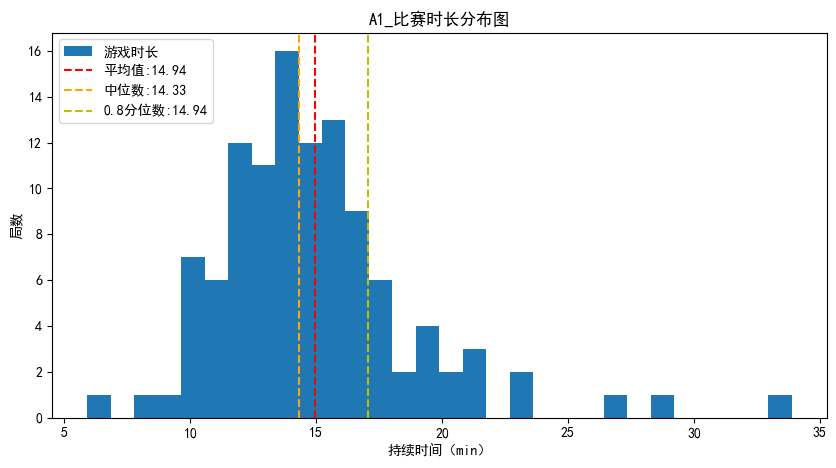

In [5]:
# TODO A1：画时长直方图
# 关键点：
#   - game_duration 单位是秒，画图时转换为分钟：duration_min = battles['game_duration'] / 60
#   - bins=30 看分布形状；太少看不出细节，太多噪声多
#   - plt.figure(figsize=(10, 5)) 让图大一点
#   - 必须有 title / xlabel / ylabel
#   - plt.savefig(FIG_DIR / 'A1_时长分布.png', dpi=150, bbox_inches='tight')
#   - 最后 plt.show()
#
# 可选：再叠加一个均值线 plt.axvline(mean_value, color='red', linestyle='--')

game_duration_min = battles['game_duration']/60
bins = 30

fig,ax = plt.subplots(figsize=(10,5))

plt.hist(game_duration_min,bins=bins,label='游戏时长')

ax.set_title("A1_比赛时长分布图")
ax.set_xlabel("持续时间（min）")
ax.set_ylabel("局数")

ax.grid(False)

mean_value = np.mean(game_duration_min)
median_value = np.median(game_duration_min)
quantile_80_value = np.quantile(game_duration_min,0.80)
ax.axvline(mean_value,color='r',linestyle='--',label = f'平均值:{mean_value:.2f}')
ax.axvline(median_value,color='orange',linestyle='--',label = f'中位数:{median_value:.2f}')
ax.axvline(quantile_80_value,color='y',linestyle='--',label = f'0.8分位数:{mean_value:.2f}')
ax.legend(loc = 'upper left')
plt.savefig(FIG_DIR / 'A1_时长分布.png',dpi=300,bbox_inches='tight')
plt.show()


💡 **业务洞察 A1**（必填，要有 so what）：

- 比赛时长中位数：__14.29__ 分钟
- 分布形状：____右偏__（正态/右偏/双峰？）
- so what：___超过80%的比赛在14.86分钟后结束，所以预测窗口应该高于14.86分钟___（这给我们什么启发？比如"超过 80% 的比赛在 X 分钟内结束，所以实时预测的窗口应该…"）

## A2 · 蓝红方胜率

### 业务问题

哪一方先选英雄，胜率有差异吗？

### 业务意义

- 如果差异很小（< 2%），说明 BP 机制相对公平，**模型不需要专门加阵营特征**
- 如果差异显著（> 5%），说明阵营本身就有红利，**必须作为基础特征**
- 不同游戏不一样：英雄联盟蓝方胜率约 51-52%，王者荣耀据说更接近 50%

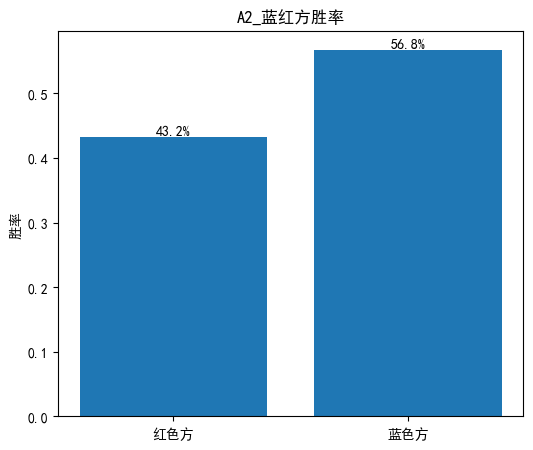

In [6]:
# TODO A2：算蓝红方胜率
# winrate = battles['win_camp'].value_counts(normalize=True)
# 然后画 plt.bar 或 sns.barplot
# 在柱子上面标具体百分比（plt.text）
# 保存到 FIG_DIR / 'A2_蓝红方胜率.png'

win_rate = battles['win_camp'].value_counts(normalize=True)

# 明确指定顺序
labels = ['红色方', '蓝色方']
values = [
    win_rate.get(2, 0),  # 假设 2=红方胜
    win_rate.get(1, 0)   # 假设 1=蓝方胜
]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, values)

# 标题与坐标轴
ax.set_title("A2_蓝红方胜率")
ax.set_ylabel("胜率")

# 在柱子顶部标百分比
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha='center',
        va='bottom'
    )

plt.grid(False)


plt.savefig(
    FIG_DIR / 'A2_蓝红方胜率.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


💡 **业务洞察 A2**：

- 蓝方胜率 __56.8__%，红方胜率 __43.2__%
- so what：是否需要加入阵营特征？为什么？

需要，因为差异较大

## A3 · 战队胜场榜（Top 10）

### 业务问题

哪些战队最强？强弱差距有多大？

### 难点

`battles.win_camp` 只是个 1/2 标签，不是战队名字。需要：

```python
# 衍生一列：胜方的战队名
battles['winner'] = np.where(battles['win_camp'] == 1,
                              battles['camp1_team_name'],
                              battles['camp2_team_name'])
# 然后 value_counts() 取 Top 10
```

> `np.where(条件, 条件成立时的值, 条件不成立时的值)`——这是行级条件表达式的标配写法。

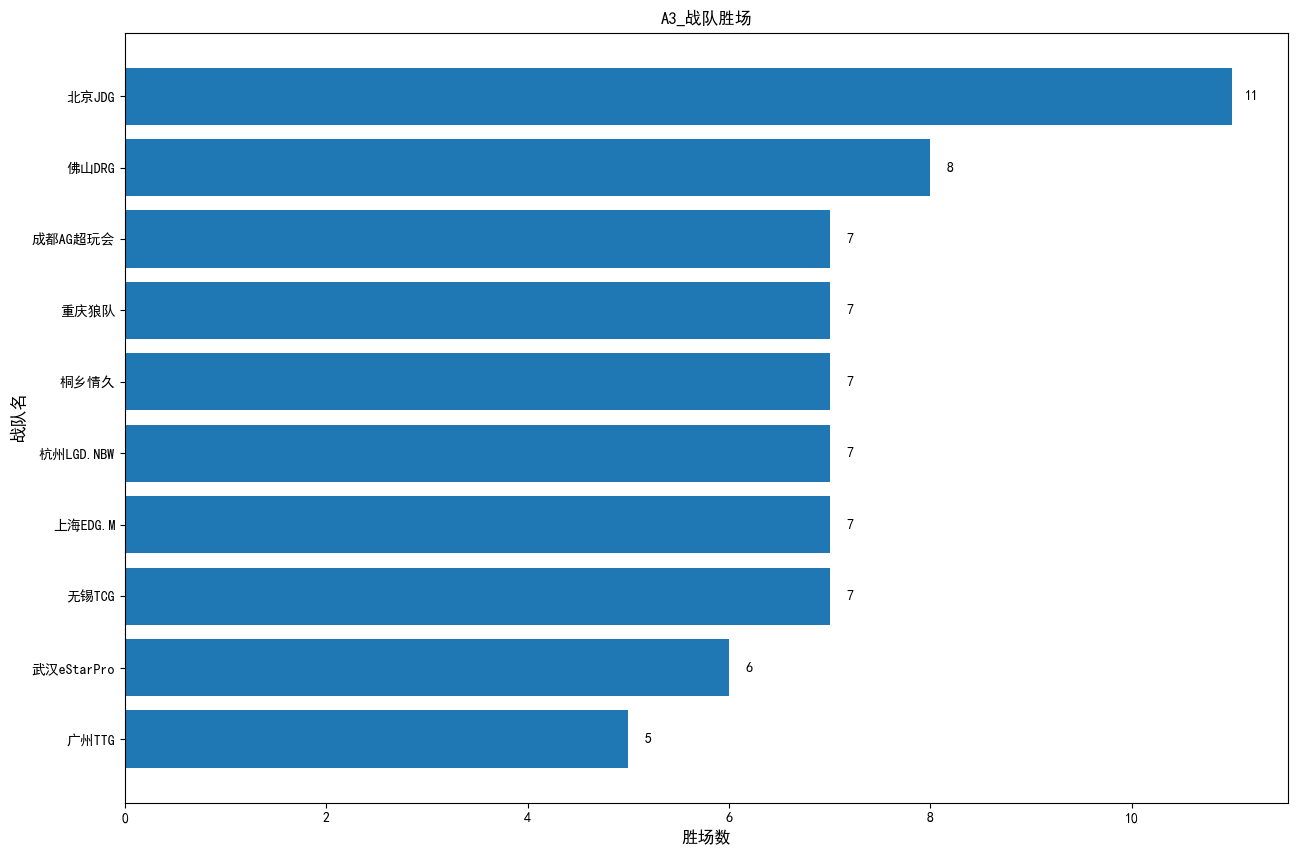

In [7]:
# TODO A3：战队胜场 Top 10 横向条形图
# 提示：
#   - sns.barplot(x=胜场数, y=战队名, orient='h') 或 .plot.barh()
#   - 横向比纵向好——战队名长，纵向放不下会被截断
#   - 排序：sort_values 让多的在上面
# 保存到 FIG_DIR / 'A3_战队胜场Top10.png'

battles["winner"] = np.where(battles['win_camp'] ==1,battles['camp1_team_name'],battles['camp2_team_name'])

winner = battles['winner'].value_counts()
# Top10
winner_top10 = winner.head(10).sort_values()

plt.figure(figsize=(15,10))
plt.barh(winner_top10.index,winner_top10.values,align='center')
plt.title('A3_战队胜场')
plt.xlabel('胜场数',size='large')
plt.ylabel('战队名',size='large')
for i,v in enumerate(winner_top10.values):
	plt.text(v+0.2,i,str(v),ha='center',va='center')
plt.savefig(FIG_DIR/"A3_战队胜场对比图.png",dpi=300,bbox_inches='tight')
plt.show()

💡 **业务洞察 A3**：

- Top 3 战队是：__JDG,DRG,EDGM____
- 第 1 名比第 10 名胜场多 __2.2__ 倍
- 强弱悬殊大 / 中等 / 还行（写哪一个）：___中等___
- so what：______（强弱悬殊大 → 战队这个特征对模型贡献会很显著）

---
# 模块 B · 选手维度

## B1 · KDA 排行（Top 10）

### 业务问题

谁是 KPL 的明星选手？

### 公式

```
KDA = (击杀 + 助攻) / max(死亡, 1)
```

`max(death, 1)` 是为了避免 0 除——某些选手某场死亡数 = 0，KDA 会爆炸成 inf。

### 关键点：最小局数限制

如果某选手只打 1 场就上榜（比如临时替补），他的"KDA = 9.0"是噪声，不是真实水平。

**所以 group 之后要过滤 `局数 >= N` 的选手**（建议 N=20，能反映稳定水平）。这是数据分析里的常见操作叫"防止小样本干扰"。

In [8]:
# TODO B1：算选手 KDA + 画 Top 10
# 提示（注意实际列名是 kill_num / death_num / assist_num）：
#   stat = players.groupby('player_name').agg(
#       games=('battle_id', 'count'),
#       kill=('kill_num', 'sum'),
#       death=('death_num', 'sum'),
#       assist=('assist_num', 'sum'),
#   )
#   stat['kda'] = (stat.kill + stat.assist) / stat.death.clip(lower=1)
#   top = stat[stat.games >= 20].sort_values('kda', ascending=False).head(10)
# 横向条形图，保存
#
# 或者更简单：players 表已经有 kda 列（单场 KDA），你可以直接 groupby 后 .mean()

In [9]:
stat = players.groupby('player_name').agg(
	games = ("battle_id","count"),
	kill = ('kill_num',sum),
	death = ('death_num',sum),
	assist = ('assist_num',sum)
)

stat['kda'] = (stat.kill + stat.assist) / stat.death.clip(lower=1)
top = stat[stat.games >= 5].sort_values('kda',ascending=False).head(10)

In [10]:
top

,games,kill,death,assist,kda
player_name,,,,,
道崽,7,37,1,40,77.000000
紫幻,7,13,2,57,35.000000
小落,8,19,2,39,29.000000
皖皖,7,19,3,49,22.666667
小久,8,34,3,29,21.000000
花卷,9,13,5,54,13.400000
九尾,8,10,5,54,12.800000
小崽,8,2,6,71,12.166667
晴空,7,11,4,37,12.000000


In [11]:
stat.sort_values(by = 'kda',ascending=False)

,games,kill,death,assist,kda
player_name,,,,,
道崽,7,37,1,40,77.000000
紫幻,7,13,2,57,35.000000
小落,8,19,2,39,29.000000
皖皖,7,19,3,49,22.666667
小久,8,34,3,29,21.000000
...,...,...,...,...,...
Bal,3,0,9,0,0.000000
令渲,3,0,8,0,0.000000
JenMyth,3,0,6,0,0.000000


In [12]:
stat.index

Index(['Bal', 'Daniii', 'Dr4w', 'F1', 'Fly', 'Guiyu', 'Jem', 'JenMyth',
       'Karlll', 'Lanfeng',
       ...
       '陌冷', '雨晨', '青剑', '青木', '青柚', '青柠', '青炎', '风意', '鹤辞', '黎响'],
      dtype='str', name='player_name', length=163)

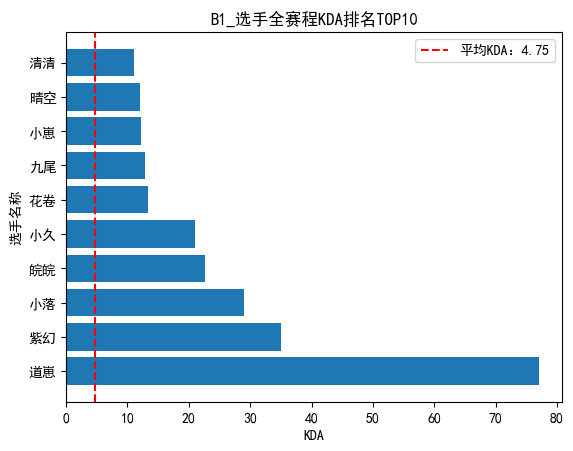

In [13]:
plt.barh(top.index,top.kda,align='center')
plt.title("B1_选手全赛程KDA排名TOP10")
plt.ylabel("选手名称")
plt.xlabel("KDA")
plt.axvline(stat.kda.mean(),color='r',linestyle='--',label = f"平均KDA：{stat.kda.mean():.2f}")
plt.legend()
plt.savefig(FIG_DIR/"B1_选手全赛程KDA排名TOP10",dpi=300,bbox_inches='tight')
plt.show()

## B2 · 胜方 vs 败方的核心数据差异

### 业务问题

胜方和败方在「击杀 / 经济 / 伤害」这些维度上分布有多大差异？

### 业务意义

这是后面建模的**重要参考**——差异越大的字段，越可能是好特征。

### 关键技巧

需要给每条 player 记录加一列「这场比赛你这边赢了没」。做法：

```python
# 把 players 跟 battles 按 battle_id join
m = players.merge(battles[['battle_id', 'win_camp']], on='battle_id')
# 选手所在的阵营 = 胜方阵营 ⇒ 这场赢了
m['is_winner'] = (m['camp'] == m['win_camp']).astype(int)
```

然后用 `seaborn.boxplot(x='is_winner', y='kill', data=m)` 看箱线图。

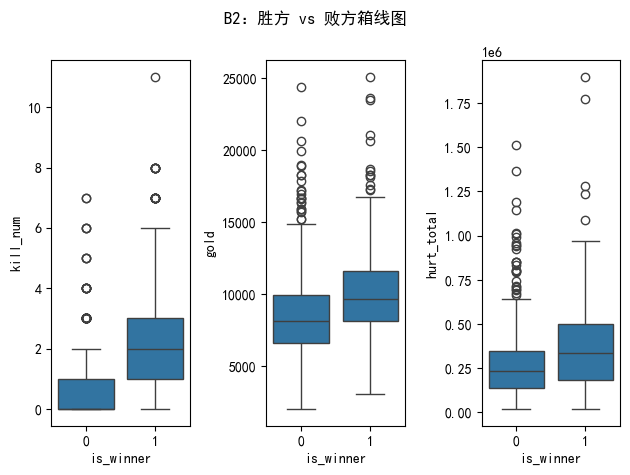

In [85]:
# TODO B2：胜方 vs 败方箱线图
# 至少画 3 个变量：kill_num / gold（经济）/ hurt_total（伤害）
# 用 plt.subplots(1, 3, figsize=(15, 4)) 把三张图并排
# 然后 sns.boxplot 各画一个
#
# 先 merge players 和 battles 拿到 is_winner：
#   m = players.merge(battles[['battle_id', 'win_camp']], on='battle_id')
#   m['is_winner'] = (m['camp'] == m['win_camp']).astype(int)

m = players.merge(battles[['battle_id','win_camp']],on = "battle_id")
m["is_winner"] = (m["camp"] == m["win_camp"]).astype(int)
plt.suptitle("B2：胜方 vs 败方箱线图")
plt.subplot(1,3,1)
winner_kill = m[m['is_winner'] == 1]['kill_num']
loser_kill = m[m['is_winner'] == 0]['kill_num']

sns.boxplot(x= 'is_winner',y="kill_num",data=m)
plt.subplot(1,3,2)
sns.boxplot(x= 'is_winner',y="gold",data=m)
plt.subplot(1,3,3)
sns.boxplot(x= 'is_winner',y="hurt_total",data=m)
plt.tight_layout()
plt.savefig(FIG_DIR/"B2_胜方 vs 败方箱线图",dpi=300,bbox_inches='tight')
plt.show()


([<matplotlib.axis.XTick at 0x20034712ad0>,
 [Text(1, 0, '败方'), Text(2, 0, '胜方')])

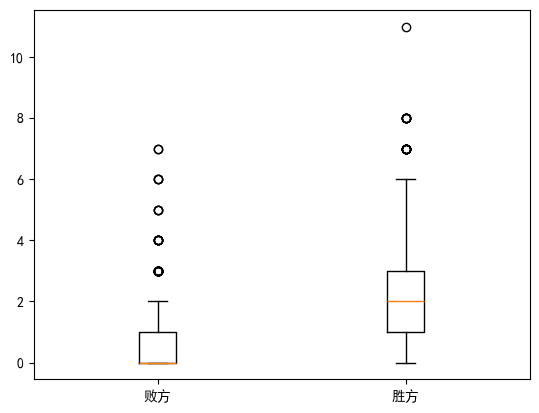

In [15]:
plt.boxplot([loser_kill,winner_kill])
plt.xticks([1,2],["败方","胜方"])

<Axes: xlabel='is_winner', ylabel='hurt_to_hero_total'>

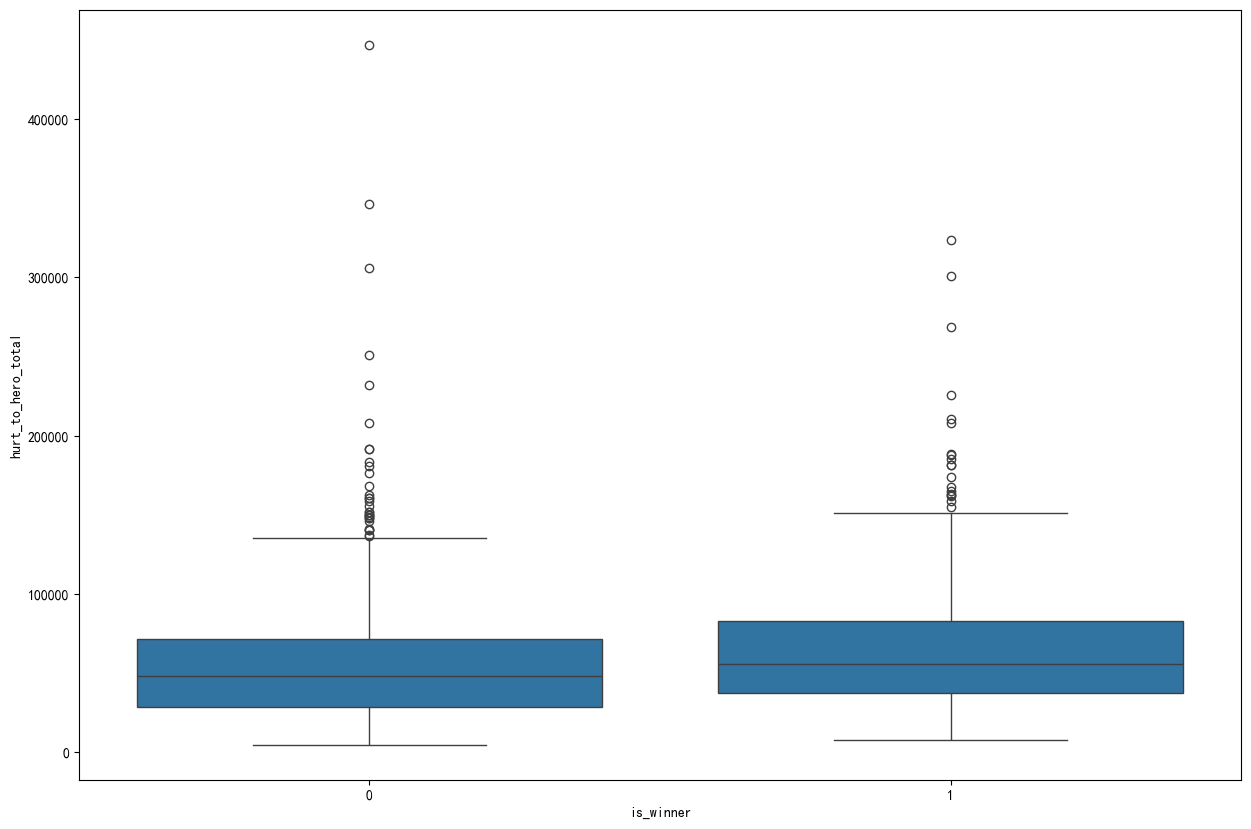

In [16]:
plt.figure(figsize=(15,10))
sns.boxplot(x= 'is_winner',y="hurt_to_hero_total",data=m)

In [ ]:
plt.figure(figsize=(15,10))
for col in m.columns:
	sns.boxplot(x= 'is_winner',y=f'{col}',data=m)
	plt.show()

💡 **业务洞察 B2**：

- 哪个变量胜败差异最大？kda
- 哪个变量胜败几乎没差异？be_hurt_by_hero_total,hurt_total_rate,be_hurt_total
- so what：______（差异大的变量适合做特征——但要警惕"赛后才知"陷阱，留到 notebook 05 处理）

---
# 模块 C · 英雄维度

## C1 · Ban / Pick 率 Top 10

### 业务问题

哪些英雄是版本宠儿（高 ban + 高 pick）？

### 公式

```
ban 率 = 该英雄被 ban 的次数 / 总场次  （注意不是 / 总操作数）
pick 率 = 该英雄被 pick 的次数 / 总场次
```

> 一场比赛**两队都可能** ban 同一英雄吗？通常 KPL 是不能的（同一英雄不能被 ban 两次也不能既 ban 又 pick）。所以分母用「总场次」而非「总操作数」。

In [50]:
# TODO C1：Ban / Pick 率 Top 10
# 提示（is_ban_or_pick: 0=ban, 1=pick）：
#   total_battles = bp['battle_id'].nunique()
#   ban_rate = bp[bp['is_ban_or_pick'] == 0]['hero_name'].value_counts() / total_battles
#   pick_rate = bp[bp['is_ban_or_pick'] == 1]['hero_name'].value_counts() / total_battles
# 然后 join 成一张表，画并排柱状图（同一英雄两根柱子，ban 一根 pick 一根）

total_battle = bp["battle_id"].nunique()
ban_rate = bp[bp['is_ban_or_pick'] == 0]['hero_name'].value_counts()/total_battle
pick_rate = bp[bp['is_ban_or_pick'] == 1]['hero_name'].value_counts()/total_battle

In [53]:
ban_pick_rate = pd.concat([ban_rate,pick_rate],axis=1)

In [54]:
ban_pick_rate

,count,count
hero_name,,
鲁班大师,0.776786,0.187500
盾山,0.651786,0.223214
关羽,0.598214,0.187500
敖隐,0.491071,0.375000
海月,0.473214,0.160714
...,...,...
桑启,NaN,0.008929
鬼谷子,NaN,0.008929
干将莫邪,NaN,0.008929


In [55]:
ban_pick_rate.columns = ['ban_rate','pick_rate']

In [59]:
ban_pick_rate['total'] = ban_pick_rate['ban_rate'] + ban_pick_rate['pick_rate']

In [62]:
ban_pick_rate.sort_values(by = ['total'],ascending = False,inplace = True)

In [ ]:
ban_pick_rate_top10 = ban_pick_rate.head(10)

In [ ]:
ban_pick_rate_top10

,ban_rate,pick_rate,total
hero_name,,,
鲁班大师,0.776786,0.187500,0.964286
盾山,0.651786,0.223214,0.875000
敖隐,0.491071,0.375000,0.866071
关羽,0.598214,0.187500,0.785714
沈梦溪,0.401786,0.312500,0.714286
大司命,0.401786,0.250000,0.651786
海月,0.473214,0.160714,0.633929
狂铁,0.250000,0.348214,0.598214
武则天,0.214286,0.321429,0.535714


<Figure size 1500x1000 with 0 Axes>

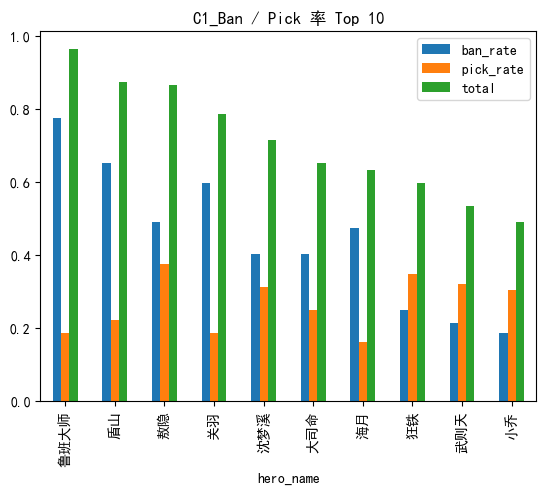

In [ ]:

plt.figure(figsize=(15,10))
ban_pick_rate_top10.plot.bar()
plt.title('C1_Ban / Pick 率 Top 10')
plt.savefig(FIG_DIR/'C1_Ban and Pick率Top10.png',dpi=300,bbox_inches='tight')
plt.show()

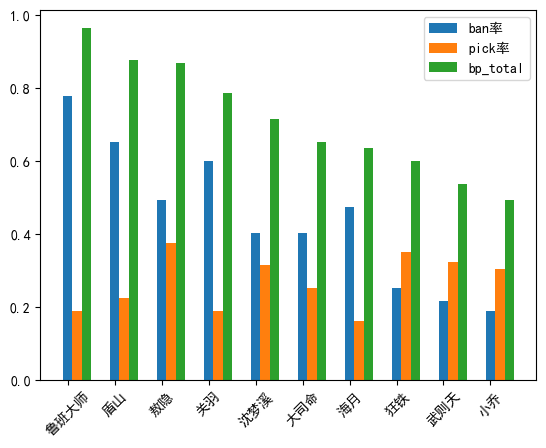

In [ ]:
x = np.arange(len(ban_pick_rate_top10))
plt.bar(x,ban_pick_rate_top10['ban_rate'],width=0.2,label='ban率')
plt.bar(x+0.2,ban_pick_rate_top10['pick_rate'],width=0.2,label = "pick率")
plt.bar(x+0.4,ban_pick_rate_top10['total'],width=0.2,label ='bp_total')
plt.legend()
plt.xticks(
    x,
    ban_pick_rate_top10.index,
    rotation=45
)

plt.show()

## C2 · 英雄胜率（被选后赢的概率）

### 业务问题

选了哪些英雄更容易赢？

### 实现思路

1. 取 bp 表中 `action == 'pick'` 的记录
2. join 到 battles 拿到每场的 `win_camp`
3. 判断 `pick.camp == win_camp` ⇒ 这次 pick 赢了
4. groupby hero 算胜率
5. **加最小被选场次限制**（比如 ≥ 10 场），同 B1

### 注意

英雄胜率 vs ban 率经常**反相关**：胜率高的容易被 ban 掉，因此 pick 率反而低。这是版本平衡的常见现象。

In [19]:
# TODO C2：英雄胜率 Top 10
# 框架（按你字段调整）：
#   picks = bp[bp['is_ban_or_pick'] == 1].merge(
#       battles[['battle_id', 'win_camp']], on='battle_id'
#   )
#   picks['won'] = (picks['camp'] == picks['win_camp']).astype(int)
#   stat = picks.groupby('hero_name').agg(
#       picks=('won', 'count'),
#       wins=('won', 'sum'),
#   )
#   stat['winrate'] = stat.wins / stat.picks
#   top = stat[stat.picks >= 10].sort_values('winrate', ascending=False).head(10)
# 画图、保存



In [133]:
pick = bp[bp['is_ban_or_pick'] == 1].merge(battles[['battle_id','win_camp']],on = "battle_id")
pick['pick_win'] = (pick.camp == pick.win_camp).astype(int)

sata = pick.groupby(by='hero_name').agg(
	picks = ('pick_win','count'),
	wins = ('pick_win','sum')
)
sata['total'] = ban_pick_rate['total']
sata['win_rate'] = sata.wins/sata.picks
top = sata[sata.picks >15].sort_values('win_rate',ascending = False).head(10)

In [134]:
top

,picks,wins,total,win_rate
hero_name,,,,
元流之子(坦克),19,13,0.419643,0.684211
夏侯惇,23,15,0.401786,0.652174
艾琳,20,13,0.232143,0.650000
戈娅,31,20,0.383929,0.645161
少司缘,32,20,0.392857,0.625000
沈梦溪,34,21,0.714286,0.617647
小乔,34,20,0.491071,0.588235
鲁班大师,21,12,0.964286,0.571429
女娲,16,9,0.294643,0.562500


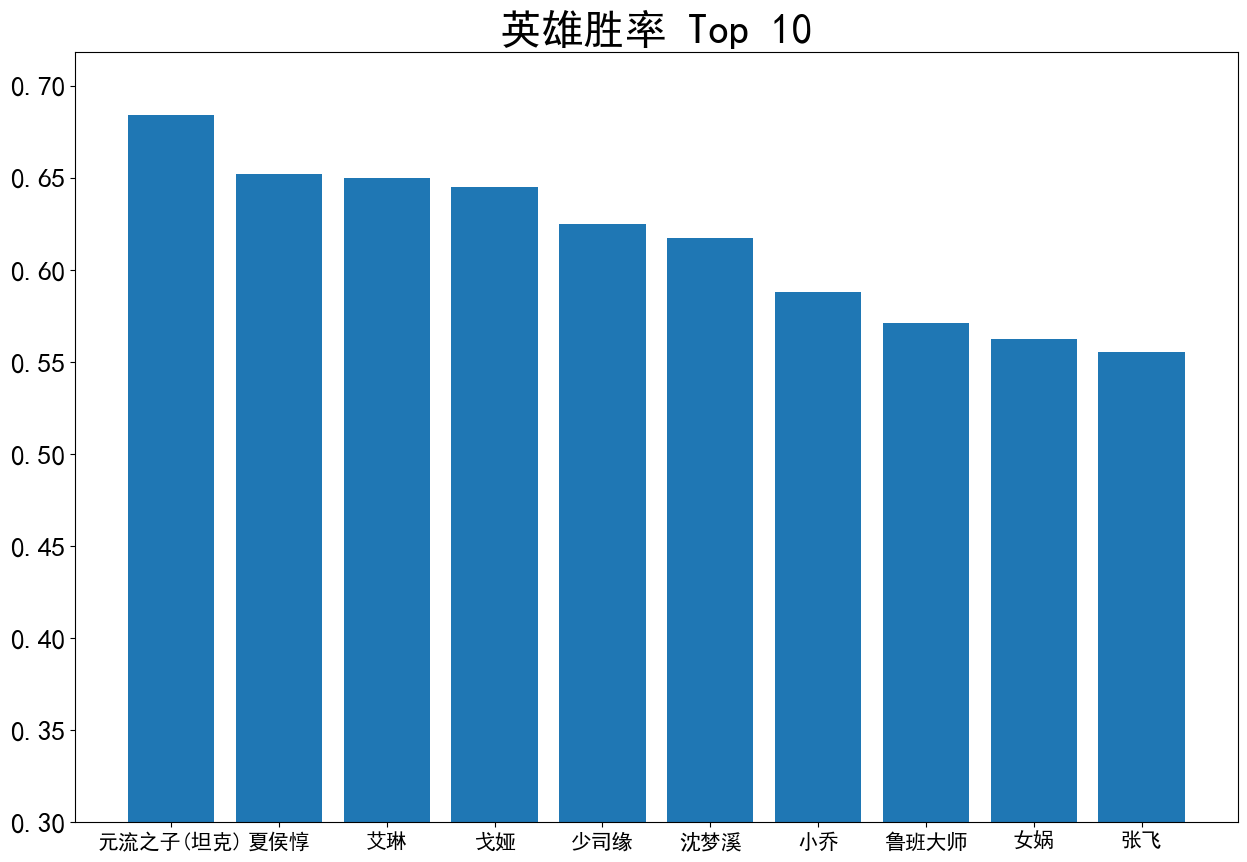

In [135]:
plt.figure(figsize=(15,10))
plt.bar(top.index,top.win_rate)
plt.title("英雄胜率 Top 10",size = 30)
plt.xticks(size = 15)
plt.yticks(size = 20)
plt.ylim(0.3)
plt.savefig(FIG_DIR/'C2_英雄胜率 Top 10',dpi=300,bbox_inches='tight')
plt.show()

💡 **业务洞察 C 模块**：

- 「版本之子」（高 ban + 高 pick + 高胜率）是哪几个英雄？__鲁班大师、沈梦溪___
- 你看到的胜率高 vs ban 率高是反相关吗？大概是
- so what：选英雄强度可以作为模型特征（每队 5 个英雄的版本胜率求和/求均）可以

---
# 模块 D · 关键变量与胜负的相关性

## D1 · 比赛级"差值特征"与胜负

### 业务问题

哪些指标的"两队差值"最能预测胜负？

### 思路

不要单看 `camp1_kill_num` 或 `camp2_kill_num`，**看双方的差值**：

```python
battles['kill_diff'] = battles['camp1_kill_num'] - battles['camp2_kill_num']
battles['gold_diff'] = battles['camp1_gold'] - battles['camp2_gold']
battles['tower_diff'] = battles['camp1_push_tower_num'] - battles['camp2_push_tower_num']
battles['camp1_win'] = (battles.win_camp == 1).astype(int)
```

然后看 `*_diff` 跟 `camp1_win` 的相关性。

### ⚠️ 关键反思

上面这些 diff 都是**比赛结束后**的统计——你之前 D 盘项目用它们做特征**就出问题了**：模型在训练集 accuracy 99%，因为它实际是「**事后诸葛亮**」。

这一步**只是探索性观察**，让我们知道哪些指标和胜负强相关。**到了 notebook 05，会严格只用「赛前可知」的字段。**

In [ ]:
# TODO D1：算 diff 特征 + 相关性热图
# 1. 衍生 *_diff 列
# 2. 算相关性矩阵：battles[['kill_diff', 'gold_diff', 'tower_diff', 'camp1_win']].corr()
# 3. sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
# 4. 看哪个 diff 跟 camp1_win 相关性最高

battles['kill_diff'] = battles['camp1_kill_num'] - battles['camp2_kill_num']

battles['gold_diff'] = battles['camp1_gold'] - battles['camp2_gold']

battles['tower_diff'] = battles['camp1_push_tower_num'] - battles['camp2_push_tower_num']

battles['camp1_win'] = ( battles['win_camp'] == 1).astype(int)

In [ ]:
corr = battles[['kill_diff','gold_diff','tower_diff','camp1_win']].corr()

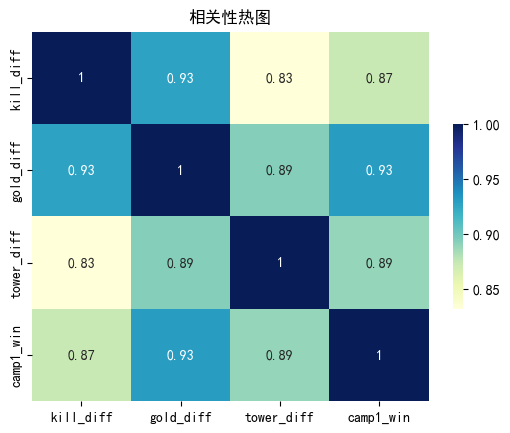

In [ ]:
sns.heatmap(corr,annot=True,cmap="YlGnBu",cbar_kws={"shrink":0.5})
plt.title("相关性热图")
plt.savefig(FIG_DIR/'D1_相关性热图',dpi=300,bbox_inches='tight')
plt.show()

💡 **业务洞察 D1**（必填，要写出"反思"）：

- kill_diff vs camp1_win 相关性：_高___
- gold_diff vs camp1_win 相关性：___非常高_
- tower_diff vs camp1_win 相关性：__高__
- 哪个最强？___gold_diff___

**关键反思**（这一段是简历/面试的高分点）：

> 上面这些指标都是赛后才能知道的，**直接拿来做模型特征会数据泄漏**——模型训练时表面看 accuracy 99%，实际上学到的是"哪个队推塔多哪个队赢"这种废话。
> 我以前的项目（指 D 盘 pythonProject5）就踩过这个坑。
> 在 notebook 05 中我会严格只用赛前可知特征：__候选赛前特征：阵营(蓝/红)、战队历史胜率、近5场胜率、BP英雄历史胜率、双方历史交手胜率____

---
## 📋 总结报告

### 模板（必填，这些就是简历项目的成果素材）

```
1. 数据规模
   - 比赛场次：__111__
   - 选手数量：__163__
   - 涉及英雄：__太多了__

2. 比赛特征
   - 平均时长：_14.94___ 分钟
   - 蓝红方胜率：__43.2%__ / _56.8%___

3. 战队层面
   - Top 3 战队：_北京JDG、佛山DRG、AG_____
   - 强弱悬殊程度：__中等____

4. 英雄层面
   - 版本之子（高 ban + 高 pick + 高胜率）：___沈梦溪、鲁班大师、女娲、少司缘、戈雅___
   - 冷门强势（低 pick 高胜率）：______（如果有）

5. 关键洞察（最重要，至少 2 条）
   - ___个别英雄bp率特别高___
   - ___金币、推塔数对胜负影响很大，但是伤害，承伤（包括伤害率、承伤率）对胜负影响，会不会需要分位置来筛选？___

6. 建模启发
   - 候选赛前特征：______
   - 不能用的字段（数据泄漏风险）：__差值字段____

7. 数据泄漏意识
   - 我意识到 ___金币差这种差值___ 字段不能直接做特征，因为 __属于数据泄露____
```

---
## ✅ 完成自检

- [ ] 至少 7 张图（A1/A2/A3 + B1/B2 + C1/C2 + D1）保存到 `reports/figures/`
- [ ] 每张图都有 title / xlabel / ylabel
- [ ] 每个 💡 业务洞察都写了，不是描述而是有"so what"
- [ ] 总结报告 7 项填完
- [ ] 标注了哪些字段有数据泄漏风险
- [ ] 列出了候选赛前特征（给 notebook 05 用）

## 🎯 完成后跟我汇报

```
1. 我做了什么：（图的清单）
2. 我的关键洞察（至少 3 条业务结论）：
   - ______
3. 我想确认：______
```